In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
np.random.seed(67)

In [21]:
#column names
colName=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Load the training data
train_df = pd.read_csv('adult/adult.data', names=colName, skipinitialspace=True)
print(f"Training data shape: {train_df.shape}")
print("\nFirst few rows:")
print(train_df.head())
print("\nData types:")
print(train_df.dtypes)
print("\nTarget distribution:")
print(train_df['income'].value_counts())


Training data shape: (32561, 15)

First few rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  

In [22]:
def labelEncode(df, column):
    # encode categorical to number
    unique_values = df[column].unique()
    mapping = {val: idx for idx, val in enumerate(unique_values)}
    return df[column].map(mapping), mapping

def preprocess_data(df, label_encoders=None, fit_encoders=False):
    df = df.copy()
    
    # Replace '?' with NaN and drop rows with missing values
    df = df.replace('?', np.nan)
    df = df.dropna()
    
    # Separate features and target
    X = df.drop('income', axis=1)
    y = df['income']
    
    # Encode target variable: '>50K' -> 1, '<=50K' -> 0
    # Strip whitespace and remove trailing periods (in test set)
    y = y.str.strip().str.rstrip('.')
    y = (y == '>50K').astype(int)
    
    # Identify categorical columns
    categorical_cols = X.select_dtypes(include=['object']).columns
    
    # Encode categorical variables manually
    if fit_encoders:
        label_encoders = {}
        for col in categorical_cols:
            X[col], mapping = labelEncode(X, col)
            label_encoders[col] = mapping
    else:
        # Use existing encoders for test data
        for col in categorical_cols:
            mapping = label_encoders[col]
            # Handle unseen categories by assigning 0
            X[col] = X[col].apply(lambda x: mapping.get(x, 0))
    
    return X.values, y.values, label_encoders

# Preprocess training data
X_train, y_train, label_encoders = preprocess_data(train_df, fit_encoders=True)

print(f"Processed training data shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"Positive class ratio: {y_train.mean():.2%}")
print(f"\nFeature statistics:")
print(f"Min values: {X_train.min(axis=0)[:5]}...")
print(f"Max values: {X_train.max(axis=0)[:5]}...")
print(f"Mean values: {X_train.mean(axis=0)[:5]}...")

Processed training data shape: (30162, 14)
Target shape: (30162,)
Positive class ratio: 24.89%

Feature statistics:
Min values: [   17     0 13769     0     1]...
Max values: [     90       6 1484705      15      16]...
Mean values: [3.84379020e+01 2.10934288e+00 1.89793834e+05 3.42460712e+00
 1.01213116e+01]...


In [23]:
test_df = pd.read_csv('adult/adult.test', names=colName, skiprows=1, skipinitialspace=True)
X_test, y_test, _ = preprocess_data(test_df, label_encoders=label_encoders, fit_encoders=False)

print(f"Test data shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

Test data shape: (15060, 14)
Test target shape: (15060,)


NEURAL NETWORK

In [ ]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    # 1 if Z>0, else 0
    return (Z > 0).astype(float)

def sigmoid(Z):
    # 1 / (1 + e^(-Z))
    return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))  # Clip to prevent overflow

def binary_cross_entropy(y_pred, y_true):
    epsilon = 1e-15  # Small value to prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    


In [25]:
class NeuralNetwork:
    def __init__(self,inSize, hidSizes, outSize):
        self.inSize=inSize
        self.outSize=outSize
        self.hidSizes=hidSizes

        self.params=self._initialize_parameters()
        self.cache={}

    # He initialisation
    def _initialize_parameters(self):

        params = {}
        
        # Layer 1: Input -> Hidden1
        params['W1'] = np.random.randn(self.inSize, self.hidSizes[0]) * np.sqrt(2 / self.inSize)
        params['b1'] = np.zeros((1, self.hidSizes[0]))
        
        # Layer 2: Hidden1 -> Hidden2
        params['W2'] = np.random.randn(self.hidSizes[0], self.hidSizes[1]) * np.sqrt(2 / self.hidSizes[0])
        params['b2'] = np.zeros((1, self.hidSizes[1]))
        
        # Layer 3: Hidden2 -> Output
        params['W3'] = np.random.randn(self.hidSizes[1], self.outSize) * np.sqrt(2 / self.hidSizes[1])
        params['b3'] = np.zeros((1, self.outSize))
        
        return params
    

    # Forward propagation
    # X -> [Linear->ReLU] -> [Linear->ReLU] -> [Linear->Sigmoid] -> Y_pred
    def forward(self, X):

        # Layer 1: Input -> Hidden1
        Z1 = np.dot(X, self.params['W1']) + self.params['b1']  # Linear transformation
        A1 = relu(Z1) 
        
        # Layer 2: Hidden1 -> Hidden2
        Z2 = np.dot(A1, self.params['W2']) + self.params['b2']
        A2 = relu(Z2)
        
        # Layer 3: Hidden2 -> Output
        Z3 = np.dot(A2, self.params['W3']) + self.params['b3']
        A3 = sigmoid(Z3)  
        
        # Store intermediate values for backpropagation
        self.cache = {
            'X': X,
            'Z1': Z1, 'A1': A1,
            'Z2': Z2, 'A2': A2,
            'Z3': Z3, 'A3': A3
        }
        
        return A3

    # Backpropagation
    def backward(self, y_true):

        m = y_true.shape[0]  
        
        X = self.cache['X']
        A1 = self.cache['A1']
        A2 = self.cache['A2']
        A3 = self.cache['A3']
        Z1 = self.cache['Z1']
        Z2 = self.cache['Z2']
        
        # Reshape y_true to match A3 shape
        y_true = y_true.reshape(-1, 1)
        
        # Output layer gradient
        # dL/dZ3 = A3 - y
        dZ3 = A3 - y_true
        
        # Gradients for W3 and b3
        dW3 = (1 / m) * np.dot(A2.T, dZ3)
        db3 = (1 / m) * np.sum(dZ3, axis=0, keepdims=True)
        
        # Hidden layer 2 gradient
        # dL/dZ2 = dL/dZ3 * dZ3/dA2 * dA2/dZ2
        dA2 = np.dot(dZ3, self.params['W3'].T)
        dZ2 = dA2 * relu_derivative(Z2)
        
        # Gradients for W2 and b2
        dW2 = (1 / m) * np.dot(A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Hidden layer 1 gradient
        dA1 = np.dot(dZ2, self.params['W2'].T)
        dZ1 = dA1 * relu_derivative(Z1)
        
        # Gradients for W1 and b1
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
        
        grads = {
            'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2,
            'dW3': dW3, 'db3': db3
        }
        
        return grads
    

    # SGD 
    # W_new = W_old - learning_rate * dL/dW
    def update_parameters(self, grads, learning_rate):
        
        self.params['W1'] -= learning_rate * grads['dW1']
        self.params['b1'] -= learning_rate * grads['db1']
        
        self.params['W2'] -= learning_rate * grads['dW2']
        self.params['b2'] -= learning_rate * grads['db2']
        
        self.params['W3'] -= learning_rate * grads['dW3']
        self.params['b3'] -= learning_rate * grads['db3']

    def predict(self, X):
        A3 = self.forward(X)
        return (A3 > 0.5).astype(int)
    
    def accuracy(self, X, y):
        predictions = self.predict(X)
        y = y.reshape(-1, 1)
        return np.mean(predictions == y)


TRAIN WITH RAW  

In [ ]:
def train_model(X_train, y_train, X_test, y_test, hidSizes, learning_rate, epochs, batch_size=64):
    model = NeuralNetwork(X_train.shape[1], hidSizes, 1)
    
    train_losses = []
    train_accuracies = []
    test_accuracies = []
    
    n_samples = X_train.shape[0]
    
    print(f"Training model with {hidSizes} hidden units...")
    print(f"Learning rate: {learning_rate}, Epochs: {epochs}, Batch size: {batch_size}\n")
    
    for epoch in range(epochs):
        # Shuffle training data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        n_batches = 0
        
        # Mini-batch training
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Forward pass
            y_pred = model.forward(X_batch)
            
            # loss
            loss = binary_cross_entropy(y_pred, y_batch)
            epoch_loss += loss
            n_batches += 1
            
            # Backward pass
            grads = model.backward(y_batch)
            
            model.update_parameters(grads, learning_rate)
        
        # Average loss for the epoch
        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        
        # acc for each 100 epoch
        if (epoch + 1) % 100 == 0 or epoch == 0:
            train_acc = model.accuracy(X_train, y_train)
            test_acc = model.accuracy(X_test, y_test)
            train_accuracies.append(train_acc)
            test_accuracies.append(test_acc)
            
            print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - "
                  f"Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")
    
    final_train_acc = model.accuracy(X_train, y_train)
    final_test_acc = model.accuracy(X_test, y_test)
    
    print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
    print(f"Final Test Accuracy: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")
    
    return model, train_losses, train_accuracies, test_accuracies

In [ ]:
model_raw, losses_raw, train_acc_raw, test_acc_raw = train_model(
    X_train, y_train, X_test, y_test,
    hidSizes=[64, 32],  
    learning_rate=0.001,
    epochs=1000,
    batch_size=64
)

Training model with [64, 32] hidden units...
Learning rate: 0.001, Epochs: 1000, Batch size: 64

Epoch 1/1000 - Loss: 0.7896 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 100/1000 - Loss: 0.5898 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 200/1000 - Loss: 0.5892 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 300/1000 - Loss: 0.5893 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 400/1000 - Loss: 0.5900 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 500/1000 - Loss: 0.5894 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 600/1000 - Loss: 0.5899 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 700/1000 - Loss: 0.5900 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 800/1000 - Loss: 0.5896 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 900/1000 - Loss: 0.5902 - Train Acc: 0.7522 - Test Acc: 0.7562
Epoch 1000/1000 - Loss: 0.5903 - Train Acc: 0.7522 - Test Acc: 0.7562
Final Training Accuracy: 0.7522 (75.22%)
Final Test Accuracy: 0.7562 (75.62%)


TRAINING WITH SCALED

In [32]:
def scale(X_train, X_test=None):
    X_min = X_train.min(axis=0)
    X_max = X_train.max(axis=0)
    
    X_range = X_max - X_min
    X_range[X_range == 0] = 1
    
    X_train_scaled = (X_train - X_min) / X_range
    
    if X_test is not None:
        X_test_scaled = (X_test - X_min) / X_range
        return X_train_scaled, X_test_scaled
    
    return X_train_scaled

X_train_scaled, X_test_scaled = scale(X_train, X_test)

print("Scaled data statistics:")
print(f"Min: {X_train_scaled.min():.6f}, Max: {X_train_scaled.max():.6f}")
print(f"Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"\nFirst 5 features range: {X_train_scaled[:, :5].min(axis=0)} to {X_train_scaled[:, :5].max(axis=0)}")

Scaled data statistics:
Min: 0.000000, Max: 1.000000
Mean: 0.234703, Std: 0.270669

First 5 features range: [0. 0. 0. 0. 0.] to [1. 1. 1. 1. 1.]


In [34]:
model_scaled, losses_scaled, train_acc_scaled, test_acc_scaled = train_model(
    X_train_scaled, y_train, X_test_scaled, y_test,
    hidSizes=[64, 32],
    learning_rate=0.01,  
    epochs=1000,
    batch_size=64
)

Training model with [64, 32] hidden units...
Learning rate: 0.01, Epochs: 1000, Batch size: 64

Epoch 1/1000 - Loss: 0.5840 - Train Acc: 0.7516 - Test Acc: 0.7544
Epoch 100/1000 - Loss: 1.0550 - Train Acc: 0.8471 - Test Acc: 0.8458
Epoch 200/1000 - Loss: 1.0819 - Train Acc: 0.8430 - Test Acc: 0.8406
Epoch 300/1000 - Loss: 1.0916 - Train Acc: 0.8520 - Test Acc: 0.8463
Epoch 400/1000 - Loss: 1.1086 - Train Acc: 0.8527 - Test Acc: 0.8443
Epoch 500/1000 - Loss: 1.1145 - Train Acc: 0.8537 - Test Acc: 0.8456
Epoch 600/1000 - Loss: 1.1297 - Train Acc: 0.8544 - Test Acc: 0.8461
Epoch 700/1000 - Loss: 1.1353 - Train Acc: 0.8481 - Test Acc: 0.8376
Epoch 800/1000 - Loss: 1.1414 - Train Acc: 0.8541 - Test Acc: 0.8460
Epoch 900/1000 - Loss: 1.1432 - Train Acc: 0.8552 - Test Acc: 0.8462
Epoch 1000/1000 - Loss: 1.1494 - Train Acc: 0.8560 - Test Acc: 0.8455
Final Training Accuracy: 0.8560 (85.60%)
Final Test Accuracy: 0.8455 (84.55%)


COMPARISION

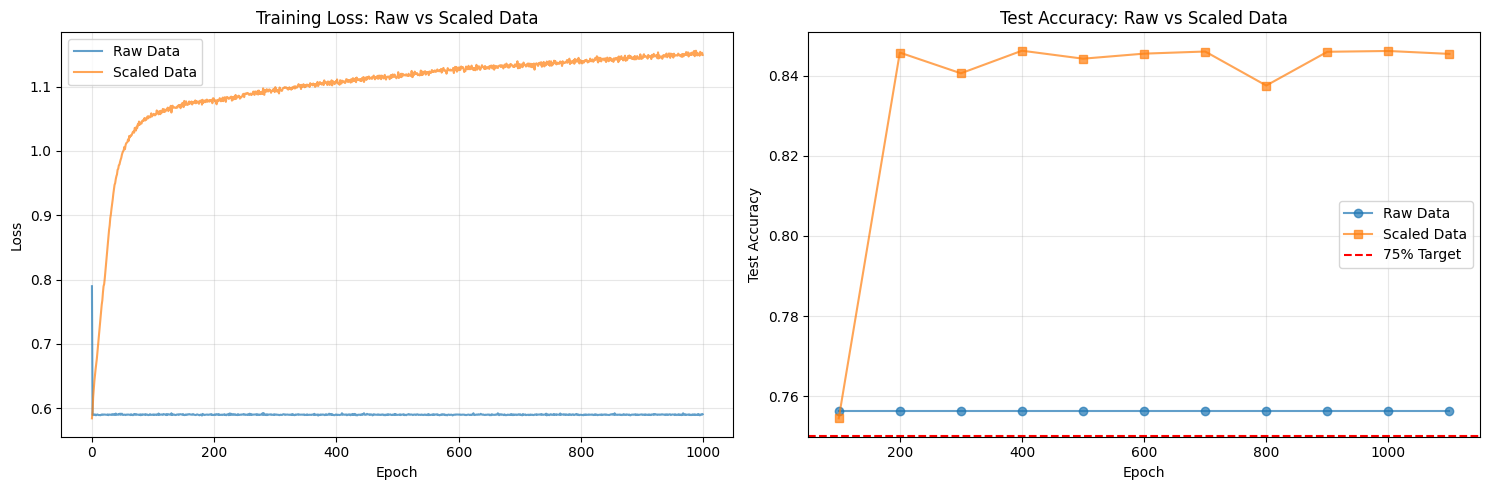

In [35]:
# loss curves
plt.figure(figsize=(15, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(losses_raw, label='Raw Data', alpha=0.7)
plt.plot(losses_scaled, label='Scaled Data', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: Raw vs Scaled Data')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy comparison
plt.subplot(1, 2, 2)
epochs_tracked = np.arange(1, len(test_acc_raw)+1) * 100
plt.plot(epochs_tracked, test_acc_raw, 'o-', label='Raw Data', alpha=0.7)
plt.plot(epochs_tracked, test_acc_scaled, 's-', label='Scaled Data', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy: Raw vs Scaled Data')
plt.axhline(y=0.75, color='r', linestyle='--', label='75% Target')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

GRADIENT ANALYSIS   

In [36]:
def analGrad(model, X, y, model_name):
    y_pred = model.forward(X[:1000])  
    grads = model.backward(y[:1000])
    
    print(f"\nGradient Analysis for {model_name}:\n")
    
    for layer in ['1','2','3']:
        w_grad = grads[f'dW{layer}']
        b_grad = grads[f'db{layer}']
        
        print(f"\nLayer {layer}:")
        print(f"  Weight gradient - Mean: {np.abs(w_grad).mean():.6f}, "
              f"Max: {np.abs(w_grad).max():.6f}, "
              f"Min: {np.abs(w_grad).min():.6f}")
        print(f"  Bias gradient   - Mean: {np.abs(b_grad).mean():.6f}, "
              f"Max: {np.abs(b_grad).max():.6f}")

analGrad(model_raw, X_train, y_train, "Raw Data Model")
analGrad(model_scaled, X_train_scaled, y_train, "Scaled Data Model")


Gradient Analysis for Raw Data Model:


Layer 1:
  Weight gradient - Mean: 0.000000, Max: 0.000000, Min: 0.000000
  Bias gradient   - Mean: 0.000000, Max: 0.000000

Layer 2:
  Weight gradient - Mean: 0.000000, Max: 0.000000, Min: 0.000000
  Bias gradient   - Mean: 0.004444, Max: 0.079292

Layer 3:
  Weight gradient - Mean: 0.000009, Max: 0.000167, Min: 0.000000
  Bias gradient   - Mean: 0.004470, Max: 0.004470

Gradient Analysis for Scaled Data Model:


Layer 1:
  Weight gradient - Mean: 0.004761, Max: 0.055648, Min: 0.000000
  Bias gradient   - Mean: 0.019094, Max: 0.085161

Layer 2:
  Weight gradient - Mean: 0.002409, Max: 0.025013, Min: 0.000000
  Bias gradient   - Mean: 0.011786, Max: 0.039161

Layer 3:
  Weight gradient - Mean: 0.007313, Max: 0.031759, Min: 0.000000
  Bias gradient   - Mean: 0.020852, Max: 0.020852
